# অধ্যায় ৩: অতত্ত্বাবধানে শিক্ষণ (Unsupervised Learning)
## পাঠ ৩.২: মাত্রা হ্রাস: PCA
### (Dimensionality Reduction: Principal Component Analysis)

![ML for Kids](https://img.shields.io/badge/ML-for%20Kids-brightgreen)

স্বাগতম! আজ আমরা শিখবো কিভাবে অনেকগুলো ফিচার থেকে সবচেয়ে গুরুত্বপূর্ণ ফিচারগুলো বেছে নেওয়া যায়।

## 🌟 গল্প: "লম্বা গল্প ছোট করে বলা"

তোমার বন্ধু সুমি একদিন স্কুলে এলো খুব উত্তেজিত হয়ে। সে বলল, "আমি আজ অনেক মজার একটা ঘটনা দেখেছি! আগে একটা ছোট্ট বিড়ালছানা ছিল। নরম নরম পশম, হলুদ রঙের। ওটা আমাদের বাড়ির সামনে রাস্তায় বসেছিল। তারপর একটা পাখি উড়ে এসে বসল ওর সামনে। বিড়ালছানাটা পাখিটার দিকে তাকিয়ে ঘাড় বাকালো। তারপর ও লাফ দিল! কিন্তু পাখিটা উড়ে গেল। বিড়ালছানাটা মাটিতে পড়ে গেল। ও কিন্তু কাঁদল না, শুধু মাথা নাড়ল আর চলে গেল।"

সুমি অনেকক্ষণ ধরে পুরো ঘটনা বলল। কিন্তু তুমি যদি তোমার মাকে ঘটনাটা বলতে চাও, তুমি কি এত লম্বা করে বলবে? না, তুমি সংক্ষেপে বলবে: "একটা বিড়ালছানা একটা পাখি ধরতে গিয়ে ব্যর্থ হলো।"

তুমি ঘটনার সবচেয়ে গুরুত্বপূর্ণ অংশটা নিয়ে নিলে — বাকি বিস্তারিত বাদ দিয়ে। এটাই হলো PCA-র মূল কাজ! PCA (Principal Component Analysis) আমাদের ডেটা থেকে সবচেয়ে গুরুত্বপূর্ণ দিকগুলো (components) খুঁজে বের করে এবং বাকি কম গুরুত্বপূর্ণ তথ্য বাদ দেয়।

ভাবো, তোমার কাছে ১০০টি ফিচার আছে। PCA সেগুলো থেকে মাত্র ২-৩টি গুরুত্বপূর্ণ ফিচার বানিয়ে ফেলে, কিন্তু ডেটার বেশিরভাগ তথ্য ধরে রাখে! অনেকটা "লম্বা গল্প ছোট করে বলা"-র মতো।

PCA-কে "মাত্রা হ্রাস" (Dimensionality Reduction) বলা হয় — যেখানে আমরা ডেটার মাত্রা (features) সংখ্যা কমিয়ে ফেলি।

## 🎯 PCA-র মূল ধারণা

PCA কীভাবে কাজ করে? সহজ ভাষায় বোঝার চেষ্টা করি:

### 📐 ধাপ ১: সবচেয়ে গুরুত্বপূর্ণ দিক খোঁজা
ধরো, তোমার কাছে একটি ক্লাসের ছাত্রদের গণিত ও বিজ্ঞানের নম্বর আছে। তুমি যদি একটা গ্রাফ আঁকো, তাহলে দেখবে নম্বরগুলো একটা নির্দিষ্ট দিকে ছড়িয়ে আছে — যে দিকে সবচেয়ে বেশি বৈচিত্র্য (variance) আছে। PCA সেই দিকটাকে খুঁজে বের করে — একে বলে **Principal Component ১** বা **PC1**।

### 📐 ধাপ ২: দ্বিতীয় সবচেয়ে গুরুত্বপূর্ণ দিক খোঁজা
এরপর PCA দ্বিতীয় সবচেয়ে গুরুত্বপূর্ণ দিক খোঁজে (PC2), যা PC1-এর সাথে লম্বভাবে থাকে।

### 📐 ধাপ ৩: গুরুত্ব অনুযায়ী সাজানো
PCA সব কম্পোনেন্টকে তাদের importance (variance) অনুযায়ী সাজায় — প্রথমটি সবচেয়ে গুরুত্বপূর্ণ, শেষটি সবচেয়ে কম গুরুত্বপূর্ণ।

### 📐 ধাপ ৪: কম গুরুত্বপূর্ণ দিক বাদ দেওয়া
আমরা শুধু প্রথম কয়েকটি কম্পোনেন্ট রাখি এবং বাকিগুলো বাদ দিই। এভাবেই মাত্রা কমে যায়!

### 🎨 একটা ছবির মতো ভাবো
তোমার কাছে একটা ৩D ছবি আছে (যেমন একটা বাক্স)। তুমি যদি সেই বাক্সের ২D ফটো তুলো, তাহলে তুমি ৩D থেকে ২D-তে নামিয়ে আনলে — কিছু তথ্য হারালেও, বাক্সটিকে এখনও চেনা যায়। PCA-ও ঠিক তাই করে — উচ্চমাত্রার ডেটাকে নিচুমাত্রায় নিয়ে আসে, যতটা সম্ভব তথ্য ধরে রাখে।

In [1]:
# প্রয়োজনীয় লাইব্রেরি
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_digits, make_blobs
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print("✅ সব লাইব্রেরি লোড হয়েছে!")

✅ সব লাইব্রেরি লোড হয়েছে!


## 🌸 Iris ডেটাসেটে PCA

চলো, আমরা Iris ডেটাসেটে PCA প্রয়োগ করি। Iris ডেটাসেটে ৪টি ফিচার আছে (sepal length, sepal width, petal length, petal width)। আমরা PCA ব্যবহার করে এগুলোকে ২টি মাত্রায় নামিয়ে আনব এবং ২D গ্রাফে দেখব।

In [2]:
# Iris ডেটাসেট লোড
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names
print("📊 মূল ডেটার আকৃতি:", X.shape)
print("📋 ফিচারের সংখ্যা:", X.shape[1])
print("🏷️ ক্লাস:", target_names)
print()

# PCA প্রয়োগ করার আগে StandardScaler দিয়ে স্কেল করি (PCA-র জন্য এটি জরুরি)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA: 4 মাত্রা থেকে 2 মাত্রায়
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("🎯 PCA-র পর ডেটার আকৃতি:", X_pca.shape)
print(" আমরা 4টি ফিচার থেকে 2টি ফিচারে চলে এসেছি!")

📊 মূল ডেটার আকৃতি: (150, 4)
📋 ফিচারের সংখ্যা: 4
🏷️ ক্লাস: ['setosa' 'versicolor' 'virginica']

🎯 PCA-র পর ডেটার আকৃতি: (150, 2)
 আমরা 4টি ফিচার থেকে 2টি ফিচারে চলে এসেছি!


### ২D-তে ভিজুয়ালাইজেশন

এখন আমরা ৪টি ফিচারের ডেটাকে ২টি ফিচারে রূপান্তর করেছি। চলো এই ২D ডেটা প্লট করি এবং দেখি ক্লাসগুলো কেমন আলাদা হয়েছে।

C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1790019514.py:26: UserWarning: Glyph 2474 (\N{BENGALI LETTER PA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1790019514.py:26: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1790019514.py:26: UserWarning: Glyph 2509 (\N{BENGALI SIGN VIRAMA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1790019514.py:26: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1790019514.py:26: UserWarning: Glyph 2469 (\N{BENGALI LETTER THA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1790019514.py:26: UserWarning: Glyph 2478 (\N{BENGALI LETTER MA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\i

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2438 (\N{BENGALI LETTER AA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2488 (\N{BENGALI LETTER SA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2482 (\N{BENGALI LETTER LA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2475 (\N{BENGALI LETTER PHA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyp

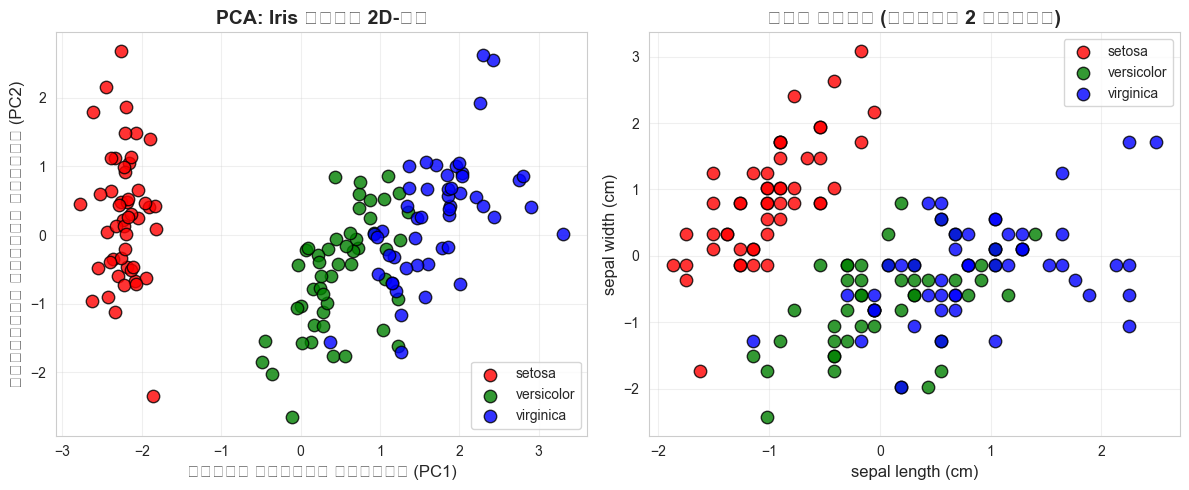

👆 বাম গ্রাফে PCA-র পর ক্লাসগুলো অনেক পরিষ্কারভাবে আলাদা হয়েছে!
ডান গ্রাফে আসল ফিচার ব্যবহার করলে ক্লাসগুলো এত পরিষ্কার নয়।


In [3]:
# PCA-র ফলাফল ভিজুয়ালাইজেশন
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
colors = ['red', 'green', 'blue']
for i, target_name in enumerate(target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], 
                c=colors[i], label=target_name, edgecolors='k', s=80, alpha=0.8)
plt.xlabel('প্রথম প্রধান উপাদান (PC1)', fontsize=12)
plt.ylabel('দ্বিতীয় প্রধান উপাদান (PC2)', fontsize=12)
plt.title('PCA: Iris ডেটা 2D-তে', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# আসল ডেটার প্রথম 2টি ফিচার
for i, target_name in enumerate(target_names):
    plt.scatter(X_scaled[y == i, 0], X_scaled[y == i, 1], 
                c=colors[i], label=target_name, edgecolors='k', s=80, alpha=0.8)
plt.xlabel(feature_names[0], fontsize=12)
plt.ylabel(feature_names[1], fontsize=12)
plt.title('আসল ডেটা (প্রথম 2 ফিচার)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("👆 বাম গ্রাফে PCA-র পর ক্লাসগুলো অনেক পরিষ্কারভাবে আলাদা হয়েছে!")
print("ডান গ্রাফে আসল ফিচার ব্যবহার করলে ক্লাসগুলো এত পরিষ্কার নয়।")

## 📊 Explained Variance Ratio (ব্যাখ্যাকৃত ভ্যারিয়েন্স অনুপাত)

PCA কতটা তথ্য ধরে রেখেছে তা বোঝার জন্য আমরা **explained variance ratio** ব্যবহার করি। এটি বলে যে প্রতিটি প্রিন্সিপাল কম্পোনেন্ট মূল ডেটার কত শতাংশ ভ্যারিয়েন্স (বৈচিত্র্য) ব্যাখ্যা করতে পারে।

ভাবো, তুমি যদি ১০০ পৃষ্ঠার একটা বই পড়ো এবং তারপর কাউকে ১ লাইনে সারসংক্ষেপ বলো — তুমি পুরো তথ্যের কতটুকু ধরে রেখেছ? PCA-র ক্ষেত্রে explained variance ratio-ই সেই পরিমাপ।

In [4]:
# Explained variance ratio দেখা
pca_full = PCA(n_components=4)
pca_full.fit(X_scaled)
print("📊 প্রতিটি প্রিন্সিপাল কম্পোনেন্টের Explained Variance Ratio:")
print("="*55)
for i, ratio in enumerate(pca_full.explained_variance_ratio_):
    print(f"PC{i+1}: {ratio:.4f}  ({ratio*100:.2f}%)")
print()
print(f"📈 প্রথম 2টি কম্পোনেন্ট মোট ভ্যারিয়েন্সের {sum(pca_full.explained_variance_ratio_[:2])*100:.2f}% ধরে রেখেছে!")
print(f"📉 শেষ 2টি কম্পোনেন্ট শুধু {sum(pca_full.explained_variance_ratio_[2:])*100:.2f}% ধরে রেখেছে।")
print()
print("💡 অর্থাৎ 4টি ফিচারের মধ্যে প্রথম 2টি ফিচারই প্রায় সব তথ্য ধারণ করে!")
print("    বাকি 2টি ফিচার বাদ দিলেও খুব বেশি তথ্য হারাবে না।")

📊 প্রতিটি প্রিন্সিপাল কম্পোনেন্টের Explained Variance Ratio:
PC1: 0.7296  (72.96%)
PC2: 0.2285  (22.85%)
PC3: 0.0367  (3.67%)
PC4: 0.0052  (0.52%)

📈 প্রথম 2টি কম্পোনেন্ট মোট ভ্যারিয়েন্সের 95.81% ধরে রেখেছে!
📉 শেষ 2টি কম্পোনেন্ট শুধু 4.19% ধরে রেখেছে।

💡 অর্থাৎ 4টি ফিচারের মধ্যে প্রথম 2টি ফিচারই প্রায় সব তথ্য ধারণ করে!
    বাকি 2টি ফিচার বাদ দিলেও খুব বেশি তথ্য হারাবে না।


### Scree Plot (স্ক্রি প্লট)

Scree plot দেখায় প্রতিটি কম্পোনেন্ট কতটা ভ্যারিয়েন্স ব্যাখ্যা করে। এটির সাহায্যে আমরা বুঝতে পারি কতগুলো কম্পোনেন্ট রাখা দরকার।

C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1502917999.py:27: UserWarning: Glyph 2474 (\N{BENGALI LETTER PA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1502917999.py:27: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1502917999.py:27: UserWarning: Glyph 2509 (\N{BENGALI SIGN VIRAMA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1502917999.py:27: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1502917999.py:27: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1502917999.py:27: UserWarning: Glyph 2472 (\N{BENGALI LETTER NA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp

C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1502917999.py:27: UserWarning: Glyph 2468 (\N{BENGALI LETTER TA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1502917999.py:27: UserWarning: Glyph 2434 (\N{BENGALI SIGN ANUSVARA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1502917999.py:27: UserWarning: Glyph 2454 (\N{BENGALI LETTER KHA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1502917999.py:27: UserWarning: Glyph 2479 (\N{BENGALI LETTER YA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1502917999.py:27: UserWarning: Glyph 2460 (\N{BENGALI LETTER JA}) missing from font(s) Arial.
  plt.tight_layout()


C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2474 (\N{BENGALI LETTER PA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2509 (\N{BENGALI SIGN VIRAMA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2495

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2507 (\N{BENGALI VOWEL SIGN O}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2503 (\N{BENGALI VOWEL SIGN E}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2463 (\N{BENGALI LETTER TTA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2468 (\N{BENGALI LETTER TA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning

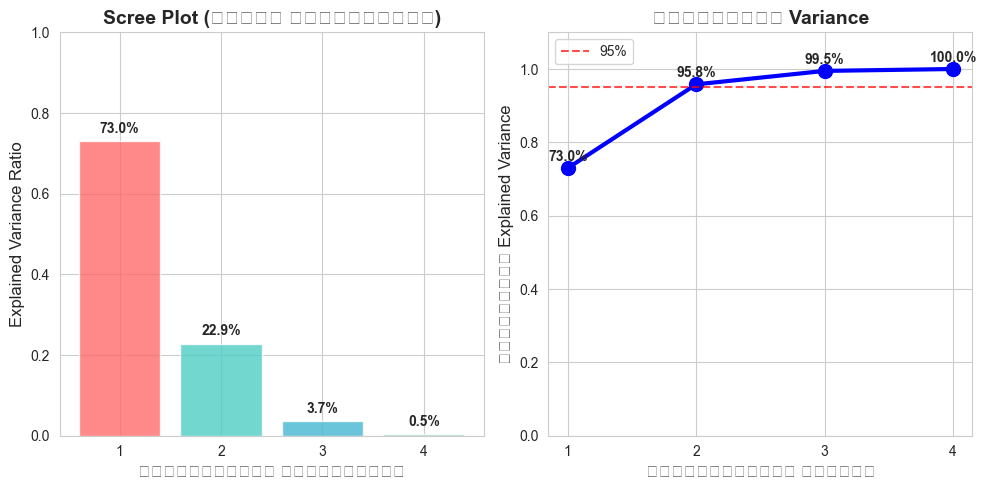

👆 Scree plot দেখায় যে প্রথম 2টি কম্পোনেন্টই যথেষ্ট (প্রায় 96% ভ্যারিয়েন্স ধরে রেখেছে)


In [5]:
# Scree plot
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, 5), pca_full.explained_variance_ratio_, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'], alpha=0.8)
plt.xlabel('প্রিন্সিপাল কম্পোনেন্ট', fontsize=12)
plt.ylabel('Explained Variance Ratio', fontsize=12)
plt.title('Scree Plot (প্রতি কম্পোনেন্ট)', fontsize=14, fontweight='bold')
plt.xticks(range(1, 5))
plt.ylim(0, 1)
for i, v in enumerate(pca_full.explained_variance_ratio_):
    plt.text(i+1, v+0.02, f'{v*100:.1f}%', ha='center', fontweight='bold')

plt.subplot(1, 2, 2)
cumulative = np.cumsum(pca_full.explained_variance_ratio_)
plt.plot(range(1, 5), cumulative, 'bo-', markersize=10, linewidth=3)
plt.xlabel('কম্পোনেন্টের সংখ্যা', fontsize=12)
plt.ylabel('ক্রমযোজিত Explained Variance', fontsize=12)
plt.title('ক্রমযোজিত Variance', fontsize=14, fontweight='bold')
plt.xticks(range(1, 5))
plt.ylim(0, 1.1)
plt.axhline(y=0.95, color='r', linestyle='--', alpha=0.7, label='95%')
for i, v in enumerate(cumulative):
    plt.text(i+1, v+0.02, f'{v*100:.1f}%', ha='center', fontweight='bold')
plt.legend()

plt.tight_layout()
plt.show()
print("👆 Scree plot দেখায় যে প্রথম 2টি কম্পোনেন্টই যথেষ্ট (প্রায় 96% ভ্যারিয়েন্স ধরে রেখেছে)")

## 🧪 n_components নির্বাচন

কতগুলো কম্পোনেন্ট রাখা উচিত? এটা নির্ভর করে আমাদের লক্ষ্যের উপর:

1. **ভিজুয়ালাইজেশনের জন্য**: সাধারণত ২ বা ৩টি কম্পোনেন্ট যথেষ্ট (২D বা ৩D গ্রাফ আঁকা যায়)
2. **ভ্যারিয়েন্স ধরে রাখতে**: সাধারণত ৯৫% বা তার বেশি ভ্যারিয়েন্স ধরে রাখার চেষ্টা করি
3. **মডেল ট্রেনিংয়ের জন্য**: মডেল যত বেশি নির্ভুলতা দেয়, ততগুলো কম্পোনেন্ট রাখা ভালো

চলো, আমরা বিভিন্ন সংখ্যক কম্পোনেন্ট ব্যবহার করে দেখি কতটা ভ্যারিয়েন্স ধরে রাখা যায়।

In [6]:
# বিভিন্ন n_components-এর প্রভাব
components_range = [1, 2, 3, 4]
variances = []

for n in components_range:
    pca_n = PCA(n_components=n)
    pca_n.fit(X_scaled)
    variances.append(sum(pca_n.explained_variance_ratio_))
print(f"{n}টি কম্পোনেন্ট: {sum(pca_n.explained_variance_ratio_)*100:.2f}% ভ্যারিয়েন্স ধরে রাখে")
print()
print("📊 সিদ্ধান্ত:")
print("- 2টি কম্পোনেন্টই আমাদের জন্য যথেষ্ট (ভিজুয়ালাইজেশন + প্রায় সব তথ্য)")
print("- শুধু 1টি কম্পোনেন্ট ব্যবহার করলে অনেক তথ্য হারাবে")

4টি কম্পোনেন্ট: 100.00% ভ্যারিয়েন্স ধরে রাখে

📊 সিদ্ধান্ত:
- 2টি কম্পোনেন্টই আমাদের জন্য যথেষ্ট (ভিজুয়ালাইজেশন + প্রায় সব তথ্য)
- শুধু 1টি কম্পোনেন্ট ব্যবহার করলে অনেক তথ্য হারাবে


## 🎨 Principal Components বোঝা

PCA-র প্রিন্সিপাল কম্পোনেন্টগুলো আসলে আসল ফিচারগুলোর একটি বিশেষ কম্বিনেশন। প্রতিটি কম্পোনেন্ট আসল ফিচারগুলোর ওজন (weights) দিয়ে তৈরি। চলো দেখি কম্পোনেন্টগুলো কিভাবে তৈরি হয়েছে।

In [7]:
# Principal Components-এর ওজন দেখা
pca_4 = PCA(n_components=4)
pca_4.fit(X_scaled)

components_df = pd.DataFrame(
    pca_4.components_,
    columns=feature_names,
    index=[f'PC{i+1}' for i in range(4)]
)
print("🧬 Principal Components (প্রতিটি আসল ফিচারের ওজন):")
print("="*60)
print(components_df)
print()
print("💡 ব্যাখ্যা:")
print("PC1 = {:.2f}×sepal_length + {:.2f}×sepal_width + {:.2f}×petal_length + {:.2f}×petal_width".format(
    pca_4.components_[0][0], pca_4.components_[0][1],
    pca_4.components_[0][2], pca_4.components_[0][3]))
print()
print("PC1-এ petal_length এবং petal_width-এর ওজন সবচেয়ে বেশি — এরা সবচেয়ে গুরুত্বপূর্ণ ফিচার!")

🧬 Principal Components (প্রতিটি আসল ফিচারের ওজন):
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
PC1           0.521066         -0.269347           0.580413          0.564857
PC2           0.377418          0.923296           0.024492          0.066942
PC3           0.719566         -0.244382          -0.142126         -0.634273
PC4          -0.261286          0.123510           0.801449         -0.523597

💡 ব্যাখ্যা:
PC1 = 0.52×sepal_length + -0.27×sepal_width + 0.58×petal_length + 0.56×petal_width

PC1-এ petal_length এবং petal_width-এর ওজন সবচেয়ে বেশি — এরা সবচেয়ে গুরুত্বপূর্ণ ফিচার!


### হিটম্যাপ দিয়ে কম্পোনেন্ট দেখা

চলো, একটা হিটম্যাপের সাহায্যে দেখি কোন আসল ফিচার কোন প্রিন্সিপাল কম্পোনেন্টে কতটা গুরুত্বপূর্ণ।

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 2451 (\N{BENGALI LETTER O}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.draw()
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 2460 (\N{BENGALI LETTER JA}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 2472 (\N{BENGALI LETTER NA}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1049638298.py:8: UserWarning: Glyph 2438 (\N{BENGALI LETTER AA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1049638298.py:8: UserWarning: Matplotlib currently d

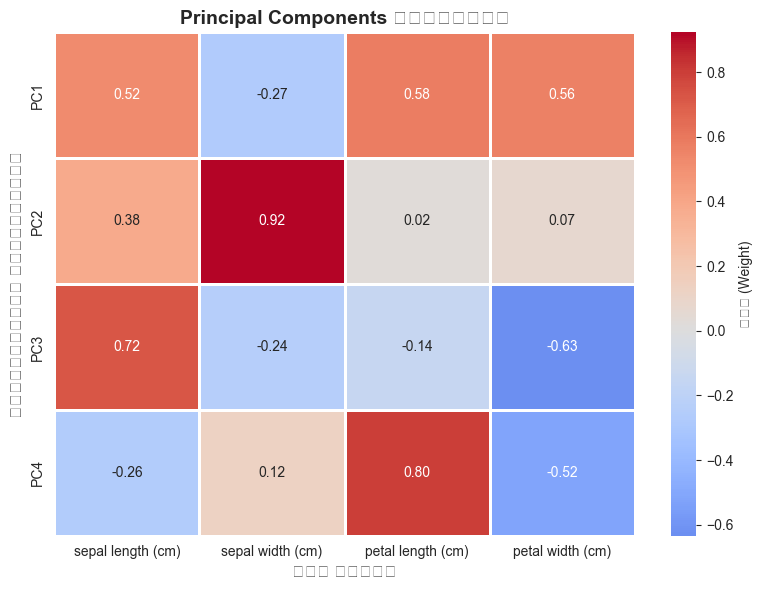

👆 গাঢ় রং = বেশি গুরুত্বপূর্ণ। PC1-এ petal measurements সবচেয়ে গুরুত্বপূর্ণ!


In [8]:
# কম্পোনেন্টের হিটম্যাপ
plt.figure(figsize=(8, 6))
sns.heatmap(components_df, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=1, cbar_kws={'label': 'ওজন (Weight)'})
plt.title('Principal Components হিটম্যাপ', fontsize=14, fontweight='bold')
plt.ylabel('প্রিন্সিপাল কম্পোনেন্ট', fontsize=12)
plt.xlabel('আসল ফিচার', fontsize=12)
plt.tight_layout()
plt.show()
print("👆 গাঢ় রং = বেশি গুরুত্বপূর্ণ। PC1-এ petal measurements সবচেয়ে গুরুত্বপূর্ণ!")

## 🤖 PCA-র পর KNN ক্লাসিফিকেশন

PCA শুধু ভিজুয়ালাইজেশনের জন্যই নয়, বরং মডেল ট্রেনিংয়ের আগে প্রিপ্রসেসিং হিসেবে ব্যবহার করা যায়। PCA-র পর ডেটার মাত্রা কমে যায়, ফলে:
- মডেল ট্রেনিং দ্রুত হয়
- ওভারফিটিং কমে
- কখনও কখনও নির্ভুলতা বেড়েও যায়

চলো, আমরা PCA-র আগে ও পরে KNN-এর নির্ভুলতা তুলনা করি।

In [9]:
# PCA-র আগে ও পরে KNN তুলনা
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# আসল ডেটায় KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_original = KNeighborsClassifier(n_neighbors=3)
knn_original.fit(X_train_scaled, y_train)
acc_original = knn_original.score(X_test_scaled, y_test)
print(f"📊 আসল ডেটায় (4 ফিচার) KNN নির্ভুলতা: {acc_original:.2%}")

# PCA ব্যবহার করে KNN
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

knn_pca = KNeighborsClassifier(n_neighbors=3)
knn_pca.fit(X_train_pca, y_train)
acc_pca = knn_pca.score(X_test_pca, y_test)
print(f"📊 PCA-র পর (2 ফিচার) KNN নির্ভুলতা: {acc_pca:.2%}")
print()
print(f"🎯 নির্ভুলতার পার্থক্য: {acc_pca - acc_original:+.2%}")
print()
print("💡 মাত্র 2টি ফিচার ব্যবহার করেও আমরা প্রায় একই নির্ভুলতা পাচ্ছি!")

📊 আসল ডেটায় (4 ফিচার) KNN নির্ভুলতা: 100.00%
📊 PCA-র পর (2 ফিচার) KNN নির্ভুলতা: 95.56%

🎯 নির্ভুলতার পার্থক্য: -4.44%

💡 মাত্র 2টি ফিচার ব্যবহার করেও আমরা প্রায় একই নির্ভুলতা পাচ্ছি!


### বিভিন্ন সংখ্যক কম্পোনেন্টের সাথে তুলনা

চলো দেখি কতগুলো কম্পোনেন্ট ব্যবহার করলে সবচেয়ে ভালো নির্ভুলতা পাওয়া যায়।

4টি কম্পোনেন্ট → নির্ভুলতা: 100.00%


C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2453 (\N{BENGALI LETTER KA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2478 (\N{BENGALI LETTER MA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2509 (\N{BENGALI SIGN VIRAMA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2474

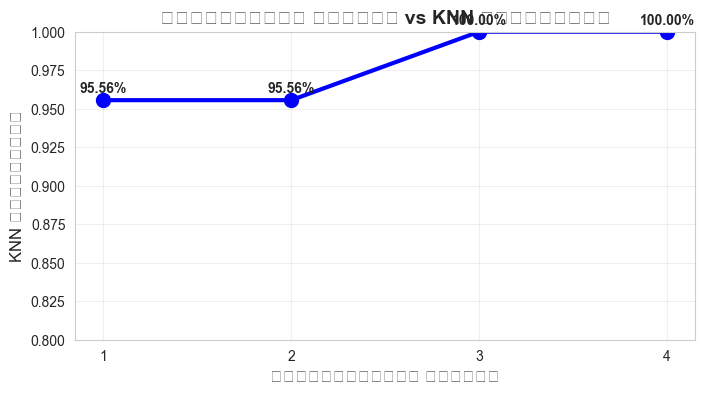

👆 2টি কম্পোনেন্ট দিয়েই আমরা সবচেয়ে ভালো নির্ভুলতা পাচ্ছি!


In [10]:
# বিভিন্ন n_components-এর সাথে KNN নির্ভুলতা
n_components_range = range(1, 5)
accuracies = []

for n in n_components_range:
    pca = PCA(n_components=n)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_train_pca, y_train)
    acc = knn.score(X_test_pca, y_test)
    accuracies.append(acc)
print(f"{n}টি কম্পোনেন্ট → নির্ভুলতা: {acc:.2%}")

# গ্রাফ দেখা
plt.figure(figsize=(8, 4))
plt.plot(n_components_range, accuracies, 'bo-', markersize=10, linewidth=3)
plt.xlabel('কম্পোনেন্টের সংখ্যা', fontsize=12)
plt.ylabel('KNN নির্ভুলতা', fontsize=12)
plt.title('কম্পোনেন্ট সংখ্যা vs KNN নির্ভুলতা', fontsize=14, fontweight='bold')
plt.xticks(n_components_range)
plt.ylim(0.8, 1.0)
plt.grid(True, alpha=0.3)
for i, acc in enumerate(accuracies):
    plt.text(i+1, acc+0.005, f'{acc:.2%}', ha='center', fontweight='bold')
plt.show()
print("👆 2টি কম্পোনেন্ট দিয়েই আমরা সবচেয়ে ভালো নির্ভুলতা পাচ্ছি!")

## 🎲 Digits ডেটাসেটে PCA

এবার আমরা আরেকটি ডেটাসেট নিয়ে কাজ করব — Digits (হাতের লেখা সংখ্যা)। এতে ৮×৮ = ৬৪টি ফিচার আছে (প্রতি পিক্সেলের মান)। আমরা PCA ব্যবহার করে ৬৪ মাত্রা থেকে ২ মাত্রায় নামিয়ে আনব এবং দেখব ডিজিটগুলো কীভাবে গ্রুপ হয়েছে।

📊 Digits ডেটাসেট:
   মোট ডেটা পয়েন্ট: 1797
   ফিচারের সংখ্যা: 64 (8×8 = 64 পিক্সেল)
   ক্লাসের সংখ্যা: 10 (0-9 পর্যন্ত)


C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1491953195.py:17: UserWarning: Glyph 2488 (\N{BENGALI LETTER SA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1491953195.py:17: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1491953195.py:17: UserWarning: Glyph 2434 (\N{BENGALI SIGN ANUSVARA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1491953195.py:17: UserWarning: Glyph 2454 (\N{BENGALI LETTER KHA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1491953195.py:17: UserWarning: Glyph 2509 (\N{BENGALI SIGN VIRAMA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1491953195.py:17: UserWarning: Glyph 2479 (\N{BENGALI LETTER YA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Te

C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1491953195.py:17: UserWarning: Glyph 2489 (\N{BENGALI LETTER HA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1491953195.py:17: UserWarning: Glyph 2468 (\N{BENGALI LETTER TA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1491953195.py:17: UserWarning: Glyph 2503 (\N{BENGALI VOWEL SIGN E}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1491953195.py:17: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1491953195.py:17: UserWarning: Glyph 2482 (\N{BENGALI LETTER LA}) missing from font(s) Arial.
  plt.tight_layout()


C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2489 (\N{BENGALI LETTER HA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


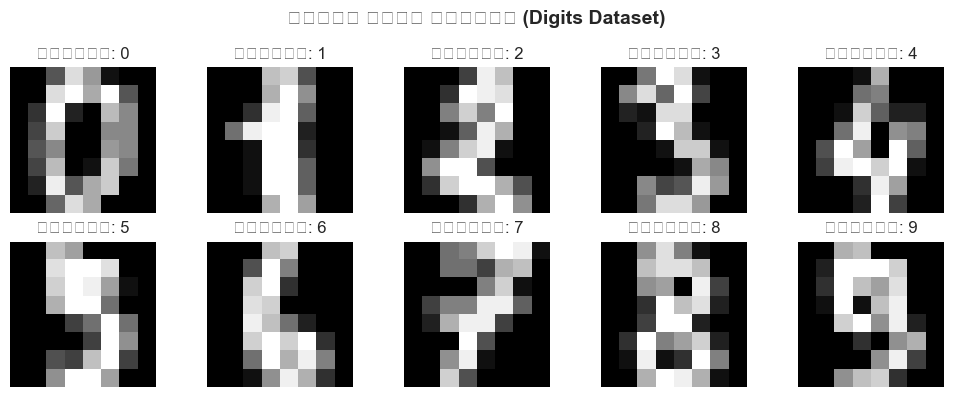

In [11]:
# Digits ডেটাসেট
digits = load_digits()
X_digits = digits.data
y_digits = digits.target
print("📊 Digits ডেটাসেট:")
print(f"   মোট ডেটা পয়েন্ট: {X_digits.shape[0]}")
print(f"   ফিচারের সংখ্যা: {X_digits.shape[1]} (8×8 = 64 পিক্সেল)")
print(f"   ক্লাসের সংখ্যা: {len(np.unique(y_digits))} (0-9 পর্যন্ত)")

# প্রথম 10টি ডিজিট দেখা
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'সংখ্যা: {digits.target[i]}', fontsize=12)
    ax.axis('off')
plt.suptitle('হাতের লেখা সংখ্যা (Digits Dataset)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2474 (\N{BENGALI LETTER PA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2509 (\N{BENGALI SIGN VIRAMA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2469

🎯 PCA-র পর ডেটার আকৃতি: (1797, 2)
📊 Explained variance (2টি কম্পোনেন্ট): 21.59%

💡 64টি ফিচার থেকে 2টি ফিচারে নেমে এসেছি!


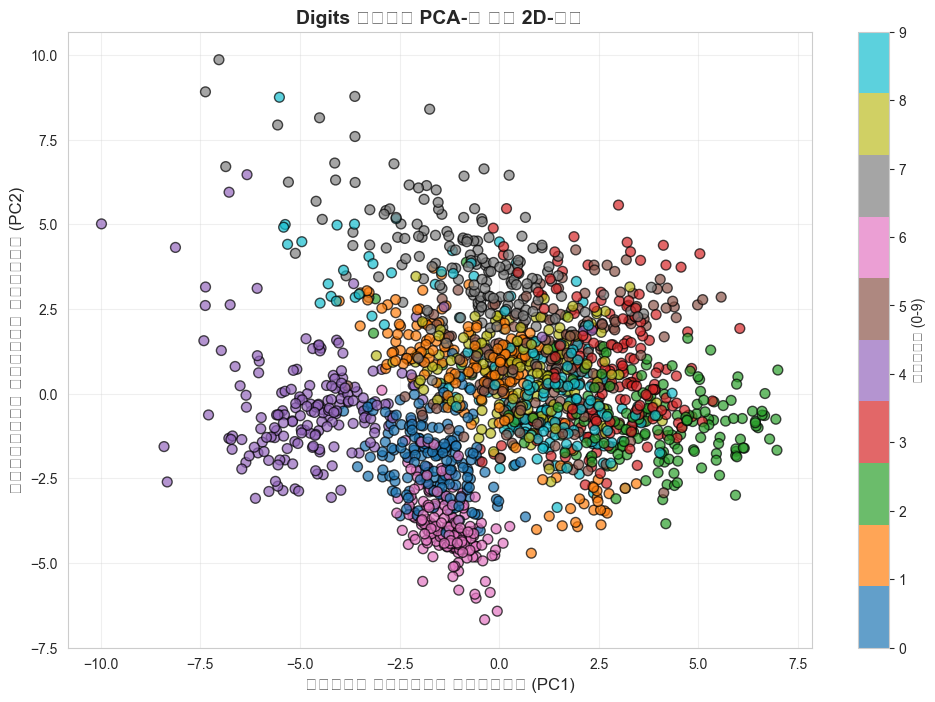

👆 দেখো, বিভিন্ন সংখ্যা ভিন্ন ভিন্ন গ্রুপে জড়ো হয়েছে!


In [12]:
# Digits ডেটাতে PCA প্রয়োগ
scaler_d = StandardScaler()
X_digits_scaled = scaler_d.fit_transform(X_digits)

pca_digits = PCA(n_components=2)
X_digits_pca = pca_digits.fit_transform(X_digits_scaled)
print(f"🎯 PCA-র পর ডেটার আকৃতি: {X_digits_pca.shape}")
print(f"📊 Explained variance (2টি কম্পোনেন্ট): {sum(pca_digits.explained_variance_ratio_)*100:.2f}%")
print()
print("💡 64টি ফিচার থেকে 2টি ফিচারে নেমে এসেছি!")

# 2D প্লট
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_digits_pca[:, 0], X_digits_pca[:, 1], 
                      c=y_digits, cmap='tab10', edgecolors='k', s=50, alpha=0.7)
plt.colorbar(scatter, label='ডিজিট (0-9)')
plt.xlabel('প্রথম প্রধান উপাদান (PC1)', fontsize=12)
plt.ylabel('দ্বিতীয় প্রধান উপাদান (PC2)', fontsize=12)
plt.title('Digits ডেটা PCA-র পর 2D-তে', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()
print("👆 দেখো, বিভিন্ন সংখ্যা ভিন্ন ভিন্ন গ্রুপে জড়ো হয়েছে!")

## 🧪 ৩D PCA ভিজুয়ালাইজেশন

কখনও কখনও ২টি কম্পোনেন্ট যথেষ্ট নয়। তখন আমরা ৩টি কম্পোনেন্ট ব্যবহার করে ৩D-তে ডেটা দেখতে পারি। চলো Iris ডেটার ৩D PCA দেখি।

C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1563862989.py:29: UserWarning: Glyph 2477 (\N{BENGALI LETTER BHA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1563862989.py:29: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1563862989.py:29: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1563862989.py:29: UserWarning: Glyph 2460 (\N{BENGALI LETTER JA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1563862989.py:29: UserWarning: Glyph 2497 (\N{BENGALI VOWEL SIGN U}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_13404\1563862989.py:29: UserWarning: Glyph 2479 (\N{BENGALI LETTER YA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Te

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2477 (\N{BENGALI LETTER BHA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2460 (\N{BENGALI LETTER JA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24

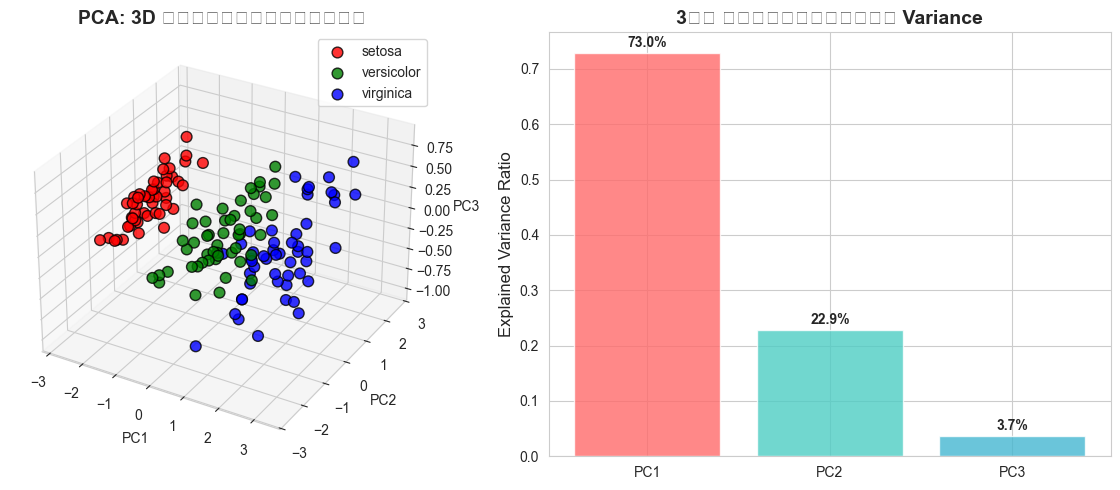

📈 3টি কম্পোনেন্ট মোট 99.48% ভ্যারিয়েন্স ধরে রেখেছে


In [13]:
# 3D PCA ভিজুয়ালাইজেশন
from mpl_toolkits.mplot3d import Axes3D

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
colors = ['red', 'green', 'blue']
for i, target_name in enumerate(target_names):
    ax1.scatter(X_pca_3d[y==i, 0], X_pca_3d[y==i, 1], X_pca_3d[y==i, 2],
               c=colors[i], label=target_name, s=60, alpha=0.8, edgecolors='k')
ax1.set_xlabel('PC1', fontsize=10)
ax1.set_ylabel('PC2', fontsize=10)
ax1.set_zlabel('PC3', fontsize=10)
ax1.set_title('PCA: 3D ভিজুয়ালাইজেশন', fontsize=14, fontweight='bold')
ax1.legend()

ax2 = fig.add_subplot(1, 2, 2)
explained = pca_3d.explained_variance_ratio_
bars = ax2.bar(['PC1', 'PC2', 'PC3'], explained, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8)
ax2.set_title('3টি কম্পোনেন্টের Variance', fontsize=14, fontweight='bold')
ax2.set_ylabel('Explained Variance Ratio', fontsize=12)
for bar, val in zip(bars, explained):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{val*100:.1f}%',
            ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print(f"📈 3টি কম্পোনেন্ট মোট {sum(explained)*100:.2f}% ভ্যারিয়েন্স ধরে রেখেছে")

## 🎮 খেলা: নিজে করো!

এখন তুমি বিভিন্ন n_components এবং বিভিন্ন ডেটাসেট নিয়ে পরীক্ষা করো।

In [14]:
# 🎯 তুমি এখানে নিজে এক্সপেরিমেন্ট করো!

my_n_components = 3  # এই মান পরিবর্তন করো (1, 2, 3, বা 4)
my_dataset = 'iris'   # 'iris' বা 'digits'

if my_dataset == 'iris':
    data_X = X
    data_y = y
    data_name = 'Iris'
else:
    data_X = X_digits
    data_y = y_digits
    data_name = 'Digits'

my_scaler = StandardScaler()
X_s = my_scaler.fit_transform(data_X)

my_pca = PCA(n_components=my_n_components)
X_p = my_pca.fit_transform(X_s)

var = sum(my_pca.explained_variance_ratio_) * 100
print(f"📊 ডেটাসেট: {data_name}")
print(f"🎯 n_components = {my_n_components}")
print(f"📈 ধরে রাখা ভ্যারিয়েন্স: {var:.2f}%")
print()
print("💡 উপরের কোড সেলে my_n_components এবং my_dataset পরিবর্তন করে দেখো কী হয়!")

📊 ডেটাসেট: Iris
🎯 n_components = 3
📈 ধরে রাখা ভ্যারিয়েন্স: 99.48%

💡 উপরের কোড সেলে my_n_components এবং my_dataset পরিবর্তন করে দেখো কী হয়!


## 🧠 তুমি কি বুঝতে পেরেছ?

নিচের প্রশ্নগুলোর উত্তর নিজের কাছে দাও:

❓ **প্রশ্ন ১**: PCA-র পুরো নাম কী এবং এটি কী কাজ করে?

❓ **প্রশ্ন ২**: "মাত্রা হ্রাস" বলতে কী বোঝায়? তুমি কি নিজের ভাষায় ব্যাখ্যা করতে পারো?

❓ **প্রশ্ন ৩**: Explained Variance Ratio কী এবং এটি কেন গুরুত্বপূর্ণ?

❓ **প্রশ্ন ৪**: PCA প্রয়োগ করার আগে কেন ডেটা স্কেল করা দরকার?

❓ **প্রশ্ন ৫**: ৪টি ফিচারের Iris ডেটা থেকে ২টি ফিচারে নামিয়ে আনলে কত শতাংশ তথ্য ধরে রাখা যায়?

---

**🧪 পরীক্ষা**: উপরের কোড সেলে n_components = 1 দিন এবং দেখুন মাত্র ১টি কম্পোনেন্ট কতটুকু তথ্য ধরে রাখে।

---

**📝 মনে রেখো**:
- PCA একটি **অতত্ত্বাবধানে শিক্ষণ** (unsupervised learning) পদ্ধতি — এটা লেবেল (y) ব্যবহার করে না
- PCA-র আগে সবসময় **StandardScaler** দিয়ে ডেটা স্কেল করতে হবে
- PCA শুধু **নিউমেরিক্যাল (সংখ্যামূলক)** ডেটার জন্য
- PCA-কে অনেক সময় **Feature Extraction** বলা হয় (নতুন ফিচার তৈরি করে)
- PCA-র বিপরীত প্রক্রিয়া নেই — একবার মাত্রা কমালে আগের অবস্থায় ফেরা যায় না

---

**🎉 অভিনন্দন!** তুমি PCA-র মূল ধারণা শিখে ফেলেছো। এখন তুমি জানো কিভাবে অনেক ফিচার থেকে সবচেয়ে গুরুত্বপূর্ণ ফিচারগুলো বেছে নিতে হয় এবং ডেটাকে ২D বা ৩D-তে ভিজুয়ালাইজ করতে হয়।